In [2]:
!pip install rdatasets

     ---------------------------------------- 0.0/44.8 kB ? eta -:--:--
     --------- ------------------------------ 10.2/44.8 kB ? eta -:--:--
     ----------------- -------------------- 20.5/44.8 kB 165.2 kB/s eta 0:00:01
     ----------------- -------------------- 20.5/44.8 kB 165.2 kB/s eta 0:00:01
     -------------------------- ----------- 30.7/44.8 kB 131.3 kB/s eta 0:00:01
     -------------------------- ----------- 30.7/44.8 kB 131.3 kB/s eta 0:00:01
     -------------------------------------- 44.8/44.8 kB 129.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/50.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/50.1 MB 1.3 MB/s eta 0:00:40
   ---------------------------------------- 0.0/50.1 MB 991.0 kB/s eta 0:00:51
   ---------------------------------------- 0.0/50.1 MB 991.0 kB/s eta 0:00:51
   ---------------------------------------- 0.1/50.1 MB 328.2 kB/s eta 0:02:33
   ---------------------------------------- 0.1/50.1 MB 504.4 kB/s eta 

In [3]:
# Install the necessary R package if you haven't already
# !pip install rdatasets


import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
# Import the rdatasets package
from rdatasets import data as rdata

In [4]:
data = sm.datasets.get_rdataset("mtcars", "datasets").data

# Display the info
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB
None


In [5]:
# Define variables
X = sm.add_constant(data['hp'])  # Adding a constant for the intercept
y = data['mpg']

# Ensure that x and y have consistent dimensions.
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (32, 2), y shape: (32,)


In [6]:
# Fit the Regression Model
model = sm.OLS(y, X).fit()

# Display the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     45.46
Date:                Sat, 30 May 2026   Prob (F-statistic):           1.79e-07
Time:                        17:32:34   Log-Likelihood:                -87.619
No. Observations:                  32   AIC:                             179.2
Df Residuals:                      30   BIC:                             182.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.0989      1.634     18.421      0.0

In [7]:
# Extract slope and related statistics
slope = model.params['hp']
std_error = model.bse['hp']
t_statistic = model.tvalues['hp']
p_value = model.pvalues['hp']

print(f"Slope: {slope}")
print(f"Standard Error: {std_error}")
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

Slope: -0.06822827807156367
Standard Error: 0.010119303810422768
T-statistic: -6.742388542706793
P-value: 1.7878352541210553e-07


In [8]:
# Calculate confidence interval
conf_int = model.conf_int(alpha=0.05).loc['hp']
print(f"95% Confidence Interval for the slope: {conf_int}")

95% Confidence Interval for the slope: 0   -0.088895
1   -0.047562
Name: hp, dtype: float64


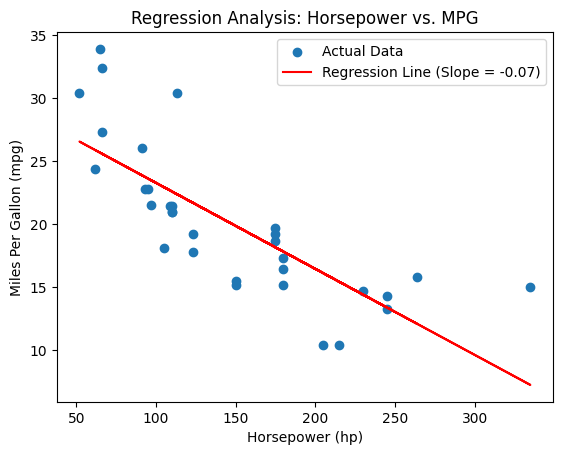

In [9]:
data['predicted_mpg'] = model.predict(X)

# Scatterplot with regression line
plt.scatter(data['hp'], data['mpg'], label='Actual Data')
plt.plot(data['hp'], data['predicted_mpg'], color='red', label=f'Regression Line (Slope = {slope:.2f})')
plt.xlabel('Horsepower (hp)')
plt.ylabel('Miles Per Gallon (mpg)')
plt.title('Regression Analysis: Horsepower vs. MPG')
plt.legend()
plt.show()